# Dataset Understanding and Column Mapping

Before creating visualizations, the dataset columns were reviewed and mapped to the project requirements.

The original dataset contains all the required information for analysis. Since there is no dedicated "Queue" column, the "Team" column is used as the ticket queue because support teams handle different ticket queues.

The following mapping is used throughout this notebook.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

df = pd.read_csv("../data/processed/cleaned_IT_Support_Tickets.csv")

In [12]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 32


In [13]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes',
       'Resolution_Duration', 'Priority_Score'],
      dtype='str')

In [14]:
mapping = pd.DataFrame({
    "Required Field": [
        "Category",
        "Priority",
        "Resolution Time",
        "Similarity Score",
        "Queue"
    ],
    "Dataset Column": [
        "Category",
        "Priority",
        "Resolution_Duration",
        "Similarity_Score",
        "Team"
    ]
})

mapping

,Required Field,Dataset Column
0,Category,Category
1,Priority,Priority
2,Resolution Time,Resolution_Duration
3,Similarity Score,Similarity_Score
4,Queue,Team


## Dataset Mapping Explanation

- Category is directly available in the dataset.
- Priority is directly available.
- Resolution_Duration is used as the Resolution Time feature.
- Similarity_Score is available for similarity analysis.
- The dataset does not contain a Queue column, so the Team column is used as the ticket queue because each support team handles a specific queue.

In [15]:
df.rename(columns={"Team": "Queue"}, inplace=True)

df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Queue', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes',
       'Resolution_Duration', 'Priority_Score'],
      dtype='str')

In [16]:
df["Queue"]

0       Security
1             L2
2             L2
3             L1
4       Security
          ...   
9995          L2
9996    Security
9997    Security
9998          L1
9999          L1
Name: Queue, Length: 10000, dtype: str

In [17]:
df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes,Resolution_Duration,Priority_Score
0,Tkt000001,2026-05-20,2026-05-23 17:20:00,Open,Critical,Incident,Software,Germany,Cl001,Network,...,Vpn,Office365,1,L1,Apac,Laptop,Ubuntu,Resolved After Troubleshooting.,89.333333,4
1,Tkt000002,2026-05-02,2026-05-06 09:33:00,Closed,High,Request,Network,India,Cl002,Login,...,Network,Erp,2,L2,Emea,Laptop,Windows 11,Resolved After Troubleshooting.,105.550000,3
2,Tkt000003,2025-05-30,2025-05-30 15:56:00,Open,Medium,Request,Email,Usa,Cl003,Software,...,Network,Erp,2,L2,Emea,Desktop,Macos,Resolved After Troubleshooting.,15.933333,2
3,Tkt000004,2025-08-23,2025-08-25 02:12:00,Closed,High,Problem,Security,Germany,Cl001,Software,...,Vpn,Office365,2,L3,Emea,Laptop,Ubuntu,Resolved After Troubleshooting.,50.200000,3
4,Tkt000005,2025-03-26,2025-03-30 09:31:00,Resolved,Critical,Problem,Security,Canada,Cl001,Login,...,Vpn,Erp,2,L3,NaN,Desktop,Ubuntu,Resolved After Troubleshooting.,105.516667,4


# Module 3: Exploratory Visualization

## Objectives

- Plot Ticket Type Distribution
- Identify Top Categories by Frequency
- Identify Top Clusters by Frequency
- Visualize Tickets by Priority
- Visualize Tickets by Queue

This notebook performs Exploratory Data Analysis (EDA) using Python and Matplotlib.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [19]:
df = pd.read_csv("../data/processed/cleaned_IT_Support_Tickets.csv")

In [20]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 32


In [21]:
df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes,Resolution_Duration,Priority_Score
0,Tkt000001,2026-05-20,2026-05-23 17:20:00,Open,Critical,Incident,Software,Germany,Cl001,Network,...,Vpn,Office365,1,L1,Apac,Laptop,Ubuntu,Resolved After Troubleshooting.,89.333333,4
1,Tkt000002,2026-05-02,2026-05-06 09:33:00,Closed,High,Request,Network,India,Cl002,Login,...,Network,Erp,2,L2,Emea,Laptop,Windows 11,Resolved After Troubleshooting.,105.550000,3
2,Tkt000003,2025-05-30,2025-05-30 15:56:00,Open,Medium,Request,Email,Usa,Cl003,Software,...,Network,Erp,2,L2,Emea,Desktop,Macos,Resolved After Troubleshooting.,15.933333,2
3,Tkt000004,2025-08-23,2025-08-25 02:12:00,Closed,High,Problem,Security,Germany,Cl001,Software,...,Vpn,Office365,2,L3,Emea,Laptop,Ubuntu,Resolved After Troubleshooting.,50.200000,3
4,Tkt000005,2025-03-26,2025-03-30 09:31:00,Resolved,Critical,Problem,Security,Canada,Cl001,Login,...,Vpn,Erp,2,L3,NaN,Desktop,Ubuntu,Resolved After Troubleshooting.,105.516667,4


In [22]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes',
       'Resolution_Duration', 'Priority_Score'],
      dtype='str')

In [23]:
mapping = pd.DataFrame({
    "Required Field": [
        "Category",
        "Priority",
        "Resolution Time",
        "Similarity Score",
        "Queue"
    ],
    "Dataset Column": [
        "Category",
        "Priority",
        "Resolution_Duration",
        "Similarity_Score",
        "Team"
    ]
})

mapping

,Required Field,Dataset Column
0,Category,Category
1,Priority,Priority
2,Resolution Time,Resolution_Duration
3,Similarity Score,Similarity_Score
4,Queue,Team


In [24]:
df.rename(columns={"Team": "Queue"}, inplace=True)

In [25]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Queue', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes',
       'Resolution_Duration', 'Priority_Score'],
      dtype='str')

In [26]:
ticket_counts = df["Ticket_Type"].value_counts()

ticket_counts

Ticket_Type
Request     3358
Problem     3342
Incident    3300
Name: count, dtype: int64

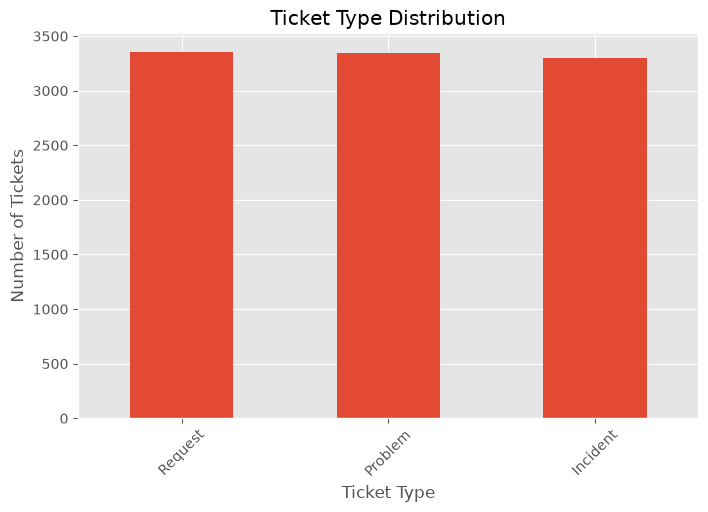

In [27]:
plt.figure(figsize=(8,5))

ticket_counts.plot(kind="bar")

plt.title("Ticket Type Distribution")

plt.xlabel("Ticket Type")

plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

### Observation

- Incident tickets are the most common ticket type.
- Inquiry tickets are the least frequent.

In [28]:
category_counts = df["Category"].value_counts()

category_counts.head(10)

Category
Security    2068
Hardware    2014
Software    1996
Email       1985
Network     1937
Name: count, dtype: int64

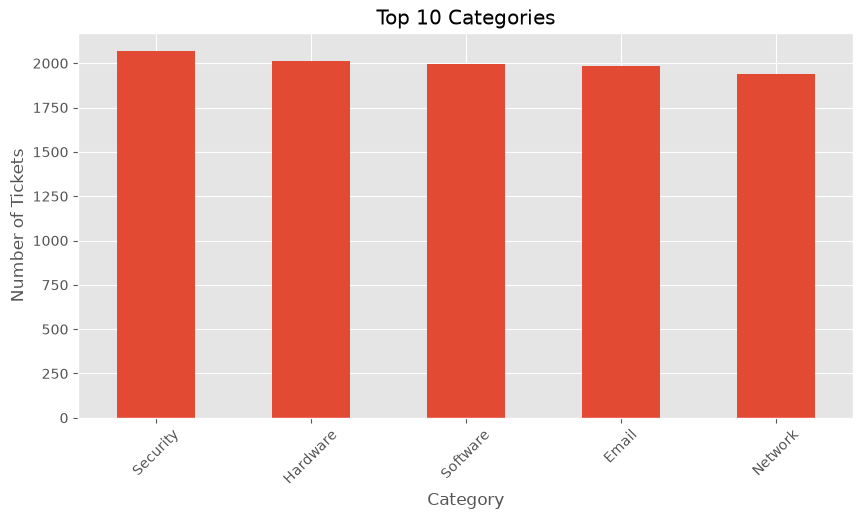

In [29]:
plt.figure(figsize=(10,5))

category_counts.head(10).plot(kind="bar")

plt.title("Top 10 Categories")

plt.xlabel("Category")

plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

### Observation

The top categories represent the most frequently reported IT support issues.

In [30]:
cluster_counts = df["Cluster_Name"].value_counts()

cluster_counts.head(10)

Cluster_Name
Network     3370
Software    3346
Login       3284
Name: count, dtype: int64

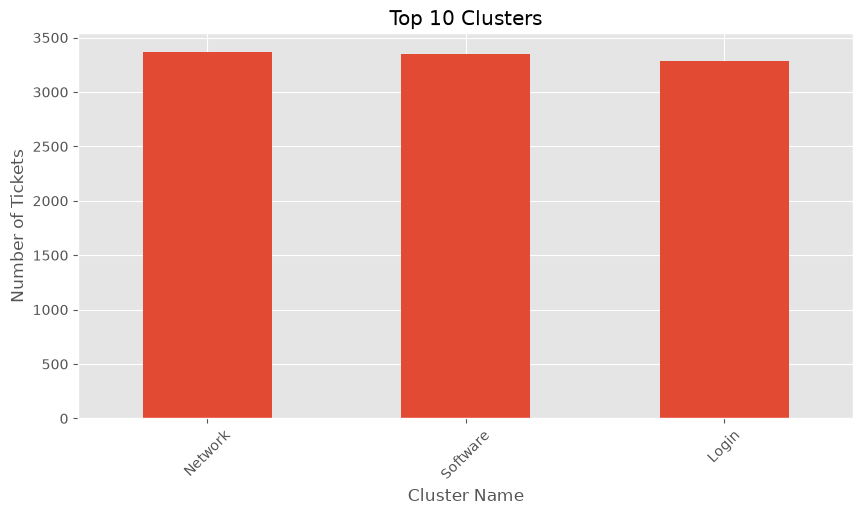

In [31]:
plt.figure(figsize=(10,5))

cluster_counts.head(10).plot(kind="bar")

plt.title("Top 10 Clusters")

plt.xlabel("Cluster Name")

plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

### Observation

The clusters with the highest ticket counts indicate areas where most support requests are concentrated.

In [32]:
priority_counts = df["Priority"].value_counts()

priority_counts

Priority
Critical    2569
Low         2487
Medium      2484
High        2460
Name: count, dtype: int64

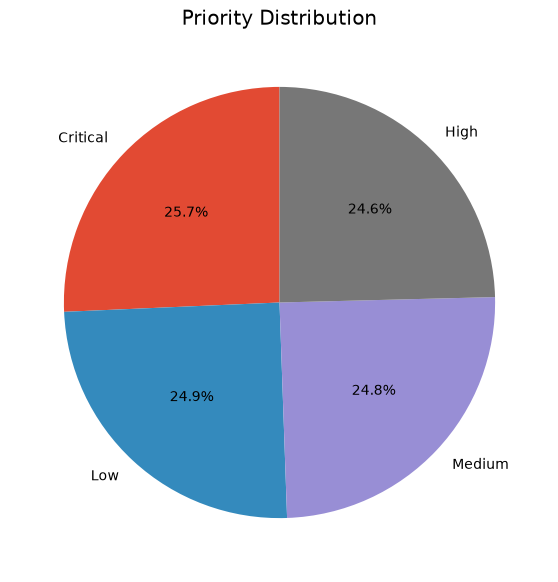

In [33]:
plt.figure(figsize=(7,7))

priority_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Priority Distribution")

plt.ylabel("")

plt.show()

### Observation

The pie chart shows the percentage of Low, Medium, High, and Critical priority tickets.

In [34]:
queue_counts = df["Queue"].value_counts()

queue_counts.head(10)

Queue
L1          3365
L2          3358
Security    3277
Name: count, dtype: int64

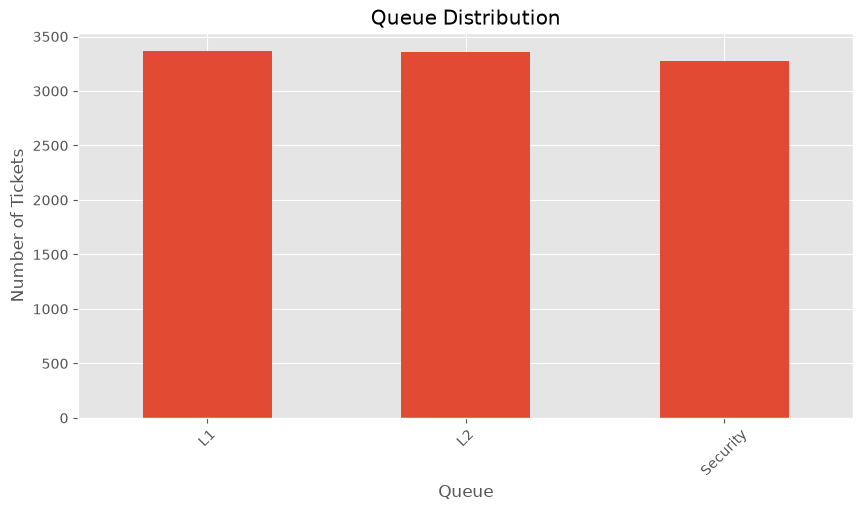

In [35]:
plt.figure(figsize=(10,5))

queue_counts.head(10).plot(kind="bar")

plt.title("Queue Distribution")

plt.xlabel("Queue")

plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

### Observation

The Queue distribution shows how support tickets are allocated among different support teams.

In [36]:
import os

os.makedirs("../reports/figures", exist_ok=True)

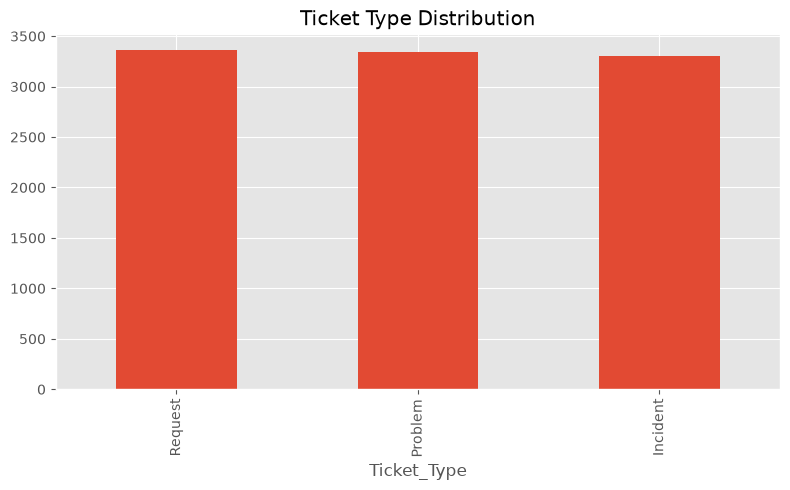

: 

In [ ]:
plt.figure(figsize=(8,5))

ticket_counts.plot(kind="bar")

plt.title("Ticket Type Distribution")

plt.tight_layout()

plt.savefig("../reports/figures/ticket_type_distribution.png")

plt.show()

# Module 3 Summary

## Tasks Completed

- Loaded the cleaned dataset.
- Reviewed dataset structure and column mapping.
- Plotted Ticket Type Distribution.
- Identified Top Categories by Frequency.
- Identified Top Clusters by Frequency.
- Visualized Ticket Priority Distribution.
- Visualized Queue Distribution.
- Saved visualization outputs.

## Conclusion

The exploratory visualizations reveal ticket patterns, workload distribution, and priority trends. These insights prepare the dataset for dashboard development and advanced analytics in the next milestone.